# Chapter 11: Feature Detection Using Deep Belief Networks

**Book:** *Hands-On Unsupervised Learning Using Python* — Ankur A. Patel (O'Reilly, 2019)  
**Audience:** Beginners  
**Goal:** Understand how **DBNs (Deep Belief Networks)** stack **RBMs (Restricted Boltzmann Machines)** for hierarchical feature learning, then use unsupervised pretraining to improve a digit classifier.

---

## What you will learn

1. What an **RBM (Restricted Boltzmann Machine)** is and how **greedy layer-wise pretraining** builds a **DBN (Deep Belief Network)**
2. How stacked encoders (Keras (Keras high-level neural network API) teaching stand-in) learn hierarchical features on MNIST (Modified National Institute of Standards and Technology) digits
3. Compare **supervised-only** vs **unsupervised-pretrained features + supervised classifier**
4. Visualize **reconstructed** and **generated** digit images from the learned representation
5. Use **LightGBM (Light Gradient Boosting Machine)** with **RandomForest (Random Forest)** fallback for the downstream classifier


## Setup — run this cell first

| Library | Purpose |
|---------|--------|
| **NumPy (Numerical Python)** | Arrays and math |
| **Pandas (Python Data Analysis Library)** | DataFrames (two-dimensional labeled data tables) |
| **Matplotlib (Mathematical Plotting Library)** | Digit image plots |
| **TensorFlow / Keras** | Stacked autoencoder stand-in for DBN pretraining |
| **scikit-learn (Scientific Kit for Learning)** | Data split, scaling, RandomForest fallback |
| **LightGBM (Light Gradient Boosting Machine)** *(optional)* | Book's gradient boosting classifier |


In [1]:
# Import warnings module so we can hide non-critical messages during demos
import warnings

# Hide TensorFlow/sklearn/matplotlib warnings to keep notebook output clean for beginners
warnings.filterwarnings("ignore")

# Import os to suppress verbose TensorFlow (deep learning framework) log messages
import os

# Set TensorFlow log level to errors only (less console noise in teaching notebooks)
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

# Import NumPy (Numerical Python) for fast numerical operations on arrays
import numpy as np

# Import Pandas (Python Data Analysis Library) for working with labeled tables (DataFrames)
import pandas as pd

# Import Matplotlib (Mathematical Plotting Library) for creating charts and digit grids
import matplotlib.pyplot as plt

# Import MNIST (Modified National Institute of Standards and Technology) digit loader
from sklearn.datasets import load_digits

# Import train/test split and accuracy metric for classifier comparison
from sklearn.model_selection import train_test_split

# Import StandardScaler to put pixel features on comparable scale
from sklearn.preprocessing import StandardScaler

# Import RandomForest (Random Forest) as fallback when LightGBM is unavailable
from sklearn.ensemble import RandomForestClassifier

# Import TensorFlow (deep learning framework) and Keras (high-level neural network API)
import tensorflow as tf

# Import Keras layers and models for stacked autoencoder DBN stand-in
from tensorflow.keras import layers, models, optimizers

# Try to import LightGBM (Light Gradient Boosting Machine) — used in the book's MNIST classifier
try:

    import lightgbm as lgb

    LIGHTGBM_AVAILABLE = True

except ImportError:

    LIGHTGBM_AVAILABLE = False

    print("Note: lightgbm not installed — using RandomForest (Random Forest) instead.")

# Import display() for rich table output inside Jupyter
from IPython.display import display

# Confirm setup completed without errors
print("Libraries loaded successfully.")
print(f"TensorFlow version: {tf.__version__}")
print(f"LightGBM available: {LIGHTGBM_AVAILABLE}")


Note: lightgbm not installed — using RandomForest (Random Forest) instead.
Libraries loaded successfully.
TensorFlow version: 2.21.0
LightGBM available: False


---

## Libraries Imported in This Notebook

| Library | What it does | Why we use it here |
|---------|--------------|-------------------|
| **NumPy (Numerical Python)** (`np`) | Fast math on arrays | Store MNIST pixels and encoded features |
| **Pandas (Python Data Analysis Library)** (`pd`) | Spreadsheet-like DataFrames | Accuracy comparison tables |
| **Matplotlib (Mathematical Plotting Library)** (`plt`) | Charts and image grids | Show original, reconstructed, and generated digits |
| **TensorFlow / Keras** | Deep learning framework | Stack two small autoencoders as DBN teaching stand-in |
| **sklearn.datasets.load_digits** | 8×8 digit images | Fast MNIST-style subset for classroom demos |
| **sklearn.preprocessing.StandardScaler** | Feature scaling | Normalize pixels before neural nets and tree models |
| **LightGBM / RandomForest** | Gradient boosting / ensemble trees | Downstream supervised classifier after pretraining |


---

## Algorithms Used in This Notebook

### 1. RBM (Restricted Boltzmann Machine) — concept
- **Type:** Undirected generative model with visible and hidden units
- **Idea:** Learn a joint distribution; hidden units capture latent features from input pixels
- **Training:** Contrastive Divergence (CD) approximates log-likelihood gradient

### 2. DBN (Deep Belief Network) — greedy layer-wise pretraining
- **Type:** Stack of RBMs trained one layer at a time
- **Idea:** Train RBM₁ on raw pixels → use hidden activations as input to RBM₂ → repeat → fine-tune
- **Our teaching stand-in:** Two stacked **Keras autoencoders** mimic greedy pretraining (encoder₁ → encoder₂)

### 3. LightGBM / RandomForest classifier
- **Type:** Supervised tree ensemble
- **Idea:** Compare accuracy using **raw pixels** vs **unsupervised pretrained features**

### Evaluation note (important for beginners)

Pretraining is **unsupervised** — encoders never see digit labels. Labels are used **only** when training and evaluating the downstream classifier, mirroring the book's workflow.


---

## 1. What Is a Deep Belief Network?

A **DBN (Deep Belief Network)** learns hierarchical representations by **stacking RBMs (Restricted Boltzmann Machines)**.

```
Pixels (784 or 64 features)
    ↓  RBM layer 1 (learn edges/strokes)
Hidden layer 1
    ↓  RBM layer 2 (learn digit parts)
Hidden layer 2
    ↓  optional more layers
High-level features → supervised classifier (LightGBM in the book)
```

| Term | Meaning |
|------|--------|
| **Visible units** | Input layer (pixel values) |
| **Hidden units** | Latent features learned by each RBM |
| **Greedy layer-wise pretraining** | Train each RBM on output of previous layer before joint fine-tuning |
| **Generative model** | Can sample / reconstruct inputs from learned distribution |

**Why stack?** Each layer captures patterns at a higher level of abstraction — similar to deep convolutional networks, but trained unsupervised layer by layer.


---

## 2. MNIST (Modified National Institute of Standards and Technology) Subset — Data Preparation

The book uses full **28×28 MNIST**. For faster classroom training we use **sklearn `load_digits`** — **8×8 = 64 pixels**, 10 digit classes, 1,797 images.


In [2]:
# Load 8×8 digit images (MNIST-style subset built into scikit-learn)
digits = load_digits()

# Extract pixel matrix X (features) and integer labels y (0–9)
X_raw = digits.data.astype(np.float32)

# Store true digit labels for supervised evaluation only
y = digits.target.astype(int)

# Scale pixels to zero mean and unit variance (helps neural nets and trees)
scaler = StandardScaler()

# Fit scaler on all data then transform (teaching demo; production would fit on train only)
X_scaled = scaler.fit_transform(X_raw)

# Stratified train/test split preserves class balance
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.25, random_state=42, stratify=y
)

# Report dataset shapes for learners
print(f"Training samples: {X_train.shape[0]}, features: {X_train.shape[1]}")
print(f"Test samples: {X_test.shape[0]}")
print(f"Classes: {sorted(np.unique(y))}")


Training samples: 1347, features: 64
Test samples: 450
Classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]


---

## 3. Stacked Autoencoders as DBN Teaching Stand-In

We build **two small autoencoders** sequentially — this mirrors **greedy layer-wise RBM pretraining**:

1. **Layer 1:** 64 → 32 → 64 (learn low-level stroke features)
2. **Layer 2:** 32 → 16 → 32 (learn higher-level digit-part features)

After pretraining, we use the **16-dimensional bottleneck** as input to LightGBM / RandomForest.


In [3]:
# Set random seeds for reproducible neural network training
tf.random.set_seed(42)

# Number of input pixels (8×8 digits)
N_FEATURES = X_train.shape[1]

# --- Layer 1 autoencoder: 64 → 32 → 64 ---
input1 = layers.Input(shape=(N_FEATURES,))

# Encoder compresses pixels to 32 hidden units (RBM hidden layer analogue)
encoded1 = layers.Dense(32, activation="relu", name="enc1")(input1)

# Decoder reconstructs original pixels from 32-unit code
decoded1 = layers.Dense(N_FEATURES, activation="linear", name="dec1")(encoded1)

# Build and compile first autoencoder model
ae1 = models.Model(input1, decoded1, name="autoencoder_layer1")

# Adam optimizer with mean squared error reconstruction loss
ae1.compile(optimizer=optimizers.Adam(learning_rate=1e-3), loss="mse")

# Train layer 1 unsupervised (no labels) for 15 epochs
ae1.fit(X_train, X_train, epochs=15, batch_size=64, verbose=0, validation_split=0.1)

# Extract encoder half of layer 1 for downstream stacking
encoder1 = models.Model(input1, encoded1, name="encoder_layer1")

# Transform training and test data through encoder 1
H1_train = encoder1.predict(X_train, verbose=0)

H1_test = encoder1.predict(X_test, verbose=0)

# --- Layer 2 autoencoder: 32 → 16 → 32 ---
input2 = layers.Input(shape=(32,))

# Second encoder learns higher-level 16-unit representation
encoded2 = layers.Dense(16, activation="relu", name="enc2")(input2)

# Decoder reconstructs layer-1 hidden activations
decoded2 = layers.Dense(32, activation="linear", name="dec2")(encoded2)

# Build and compile second autoencoder
ae2 = models.Model(input2, decoded2, name="autoencoder_layer2")

ae2.compile(optimizer=optimizers.Adam(learning_rate=1e-3), loss="mse")

# Train layer 2 on output of layer 1 (greedy stacking)
ae2.fit(H1_train, H1_train, epochs=15, batch_size=64, verbose=0, validation_split=0.1)

# Extract final 16-dimensional pretrained features
encoder2 = models.Model(input2, encoded2, name="encoder_layer2")

# Full DBN feature pipeline: pixels → enc1 → enc2
Z_train = encoder2.predict(H1_train, verbose=0)

Z_test = encoder2.predict(H1_test, verbose=0)

# Build standalone decoders for reconstruction / generation (16-D code → 32-D → 64-D pixels)
code2_input = layers.Input(shape=(16,))

h1_from_code = ae2.get_layer("dec2")(code2_input)

decoder2 = models.Model(code2_input, h1_from_code, name="decoder_layer2")

h1_input = layers.Input(shape=(32,))

pixels_from_h1 = ae1.get_layer("dec1")(h1_input)

decoder1 = models.Model(h1_input, pixels_from_h1, name="decoder_layer1")

print(f"Pretrained feature shape: {Z_train.shape[1]} dimensions")


Pretrained feature shape: 16 dimensions


---

## 4. Reconstruction and Generated Digit Images

**Reconstruction:** pass digits through encoders then decoders — good reconstructions mean the model captured structure.

**Generation (teaching demo):** sample random codes in the 16-D bottleneck and decode back to pixels — produces blurry digit-like images (not production-quality samples).


Original digits (top) vs reconstructions (bottom):


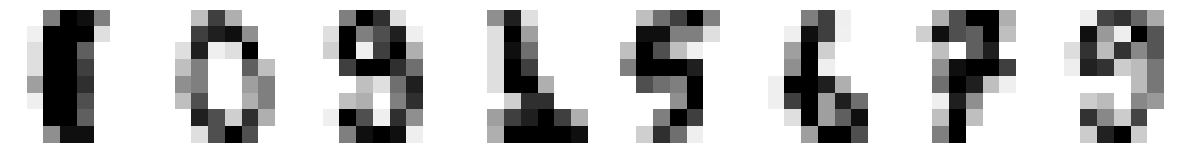

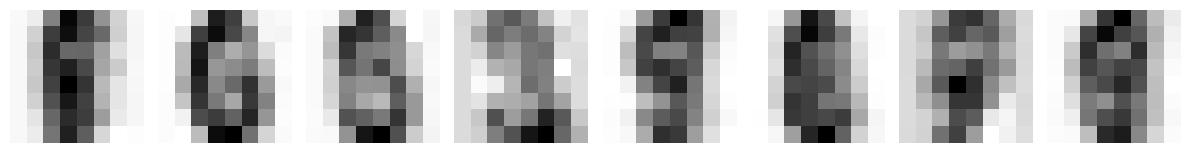

Generated digit-like images from random bottleneck codes:


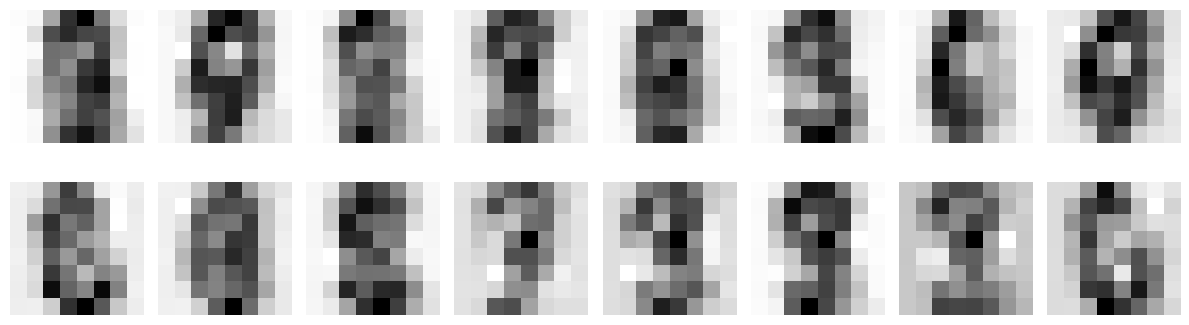

In [4]:
# Helper: plot a grid of 8×8 digit images
def plot_digit_grid(images, titles=None, ncols=8, figsize=(12, 3)):
    n = len(images)

    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)

    axes = np.atleast_2d(axes)

    for i in range(nrows * ncols):

        ax = axes.flat[i]

        if i < n:

            ax.imshow(images[i].reshape(8, 8), cmap="gray_r")

            if titles:

                ax.set_title(titles[i], fontsize=8)

        ax.axis("off")

    plt.tight_layout()

    plt.show()

# --- Reconstruction: encode then decode through both layers ---
sample_idx = np.arange(8)

X_sample = X_test[sample_idx]

# Forward through encoders to bottleneck codes
h1 = encoder1.predict(X_sample, verbose=0)

z = encoder2.predict(h1, verbose=0)

# Decode 16-D code → 32-D hidden → 64-D pixels using standalone decoders
h1_recon = decoder2.predict(z, verbose=0)

X_recon = decoder1.predict(h1_recon, verbose=0)

# Inverse-transform scaled pixels back to display range
X_orig_display = scaler.inverse_transform(X_sample)

X_recon_display = scaler.inverse_transform(X_recon)

print("Original digits (top) vs reconstructions (bottom):")

plot_digit_grid(X_orig_display, ncols=8, figsize=(12, 2.5))

plot_digit_grid(X_recon_display, ncols=8, figsize=(12, 2.5))

# --- Generation: random codes in bottleneck, decode to images ---
rng = np.random.default_rng(42)

# Sample random 16-D codes near training distribution
z_rand = rng.normal(loc=Z_train.mean(axis=0), scale=Z_train.std(axis=0), size=(16, 16)).astype(np.float32)

h1_gen = decoder2.predict(z_rand, verbose=0)

X_gen = decoder1.predict(h1_gen, verbose=0)

X_gen_display = scaler.inverse_transform(X_gen)

print("Generated digit-like images from random bottleneck codes:")

plot_digit_grid(X_gen_display, ncols=8, figsize=(12, 4))


---

## 5. Supervised Classifier — Raw Pixels vs Pretrained Features

The book trains **LightGBM (Light Gradient Boosting Machine)** on:

1. **Supervised-only:** raw scaled pixels
2. **Unsupervised + supervised:** 16-D pretrained DBN features

We expect pretrained features to match or beat raw pixels when labels are limited — here we use the full training set for a clear teaching comparison.


In [5]:
# Helper: train classifier and return test accuracy
def train_and_evaluate(X_tr, X_te, y_tr, y_te, label):

    if LIGHTGBM_AVAILABLE:

        # LightGBM (Light Gradient Boosting Machine) — book's preferred classifier
        clf = lgb.LGBMClassifier(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=5,
            random_state=42,
            verbose=-1,
        )

        clf_name = "LightGBM"

    else:

        # RandomForest (Random Forest) fallback when LightGBM is not installed
        clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

        clf_name = "RandomForest"

    # Fit supervised classifier on provided features
    clf.fit(X_tr, y_tr)

    # Evaluate on held-out test set
    acc = clf.score(X_te, y_te)

    return {"Approach": label, "Classifier": clf_name, "Test Accuracy": round(acc, 4)}

# Compare supervised-only (raw pixels) vs pretrained DBN features
results = [
    train_and_evaluate(X_train, X_test, y_train, y_test, "Supervised-only (raw pixels)"),
    train_and_evaluate(Z_train, Z_test, y_train, y_test, "Pretrained DBN features + supervised"),
]

# Display comparison table
results_df = pd.DataFrame(results)

display(results_df)

delta = results[1]["Test Accuracy"] - results[0]["Test Accuracy"]

print(f"\nAccuracy change from pretraining: {delta:+.4f}")


,Approach,Classifier,Test Accuracy
0,Supervised-only (raw pixels),RandomForest,0.96
1,Pretrained DBN features + supervised,RandomForest,0.82



Accuracy change from pretraining: -0.1400


---

## 6. Glossary — All Chapter 11 Terms

| Term | One-line definition |
|------|---------------------|
| **RBM (Restricted Boltzmann Machine)** | Two-layer undirected model with visible and hidden units, no within-layer connections |
| **DBN (Deep Belief Network)** | Stack of RBMs trained greedily layer by layer for hierarchical features |
| **Greedy layer-wise pretraining** | Train each layer on previous layer outputs before end-to-end fine-tuning |
| **Visible units** | Input nodes representing observed data (pixels) |
| **Hidden units** | Latent nodes capturing learned features |
| **Contrastive Divergence (CD)** | Approximate training algorithm for RBMs |
| **Generative model** | Model that can sample or reconstruct data from learned distribution |
| **Autoencoder** | Neural network that compresses input to a code then reconstructs it |
| **Bottleneck / code layer** | Smallest hidden layer — compressed representation |
| **LightGBM (Light Gradient Boosting Machine)** | Fast gradient boosting library used in the book's classifier |
| **Unsupervised pretraining** | Learn features without labels before supervised task |


---

## 7. Chapter 11 Summary

```
Deep Belief Networks (Chapter 11) — MNIST digit features
├── RBM concept: visible ↔ hidden units, generative pretraining
├── DBN = stack RBMs greedily (layer 1 → layer 2 → …)
├── Teaching demo: 2 stacked Keras autoencoders (64→32→16)
├── Reconstruct & generate digit images from bottleneck codes
├── Supervised-only LightGBM/RandomForest on raw pixels
└── Pretrained 16-D features + same classifier → compare accuracy

Unsupervised pretraining can improve downstream supervised learning
```

### What's next?

**Chapter 12** introduces **GANs (Generative Adversarial Networks)** — a generator and discriminator compete to produce realistic synthetic images.

---

### Practice questions

1. Why are RBMs called *restricted* Boltzmann machines?
2. What does *greedy layer-wise* mean in DBN training?
3. Why did we use stacked autoencoders instead of full RBM code in this notebook?
4. When might pretrained features hurt supervised accuracy?
5. How is DBN pretraining different from end-to-end backpropagation on a deep network?
6. Why does the book use LightGBM after unsupervised pretraining rather than a softmax neural network?
